In [18]:

# QCBM Hybrid VAE (Optimization Phase 3)
# Variational Autoencoder + Quantum Circuit Born Machine
# Goal: Force Normal data into a Gaussian Latent Space to simplify QCBM learning and distinct outlier separation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import AerSimulator
import warnings

warnings.filterwarnings('ignore')

# Configuration
DATA_PATH = 'creditcard.csv'
N_QUBITS = 10 # 32x32 Grid
N_LAYERS = 8
GRID_SIZE = 32
MAX_ITER_QCBM = 300
VAE_EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.001
SHOTS = 50000 
RANDOM_STATE = 42

print("Hybrid VAE Environment Loaded.")


Hybrid VAE Environment Loaded.


In [19]:

# --- 1. Data Loading & Split ---

def load_data(path):
    print(f"Loading data from {path}...")
    try:
        data = pd.read_csv(path)
    except FileNotFoundError:
        possible_paths = [
            '/Users/abdelhadimarjane/Downloads/creditcard.csv',
            '../creditcard.csv', 
            '/Users/abdelhadimarjane/Documents/AUI_Classes/fall 2025/quantum computing/quantum_computing/creditcard.csv'
        ]
        for p in possible_paths:
            try:
                data = pd.read_csv(p)
                print(f"Found data at {p}")
                return data
            except:
                continue
        raise FileNotFoundError("Could not find creditcard.csv")
    return data

df = load_data(DATA_PATH)

# Feature Engineering
# 1. Drop 'Time'
# 2. Log-transform 'Amount'
df['Amount'] = np.log1p(df['Amount'])
feature_cols = ['Amount'] + [f'V{i}' for i in range(1, 28)]
cols = [c for c in feature_cols if c in df.columns]

# Split Data using train_test_split (Methodologically Sound)
df_normal = df[df['Class'] == 0]
df_fraud = df[df['Class'] == 1]

train_size =  284807
if len(df_normal) > train_size:
    df_normal_train, df_normal_test = train_test_split(df_normal, train_size=train_size, random_state=RANDOM_STATE, shuffle=True)
else:
    df_normal_train, df_normal_test = train_test_split(df_normal, train_size=0.8, random_state=RANDOM_STATE, shuffle=True)

X_train_raw = df_normal_train[cols].values
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

print(f"Training VAE on {len(X_train_raw)} Normal samples.")


Loading data from creditcard.csv...
Training VAE on 227452 Normal samples.


Training VAE...
Epoch 5/100, Loss: 0.0936
Epoch 10/100, Loss: 0.0936
Epoch 15/100, Loss: 0.0936
Epoch 20/100, Loss: 0.0936
Epoch 25/100, Loss: 0.0936
Epoch 30/100, Loss: 0.0936
Epoch 35/100, Loss: 0.0935
Epoch 40/100, Loss: 0.0935
Epoch 45/100, Loss: 0.0935
Epoch 50/100, Loss: 0.0935
Epoch 55/100, Loss: 0.0935
Epoch 60/100, Loss: 0.0935
Epoch 65/100, Loss: 0.0935
Epoch 70/100, Loss: 0.0935
Epoch 75/100, Loss: 0.0935
Epoch 80/100, Loss: 0.0935
Epoch 85/100, Loss: 0.0935
Epoch 90/100, Loss: 0.0935
Epoch 95/100, Loss: 0.0935
Epoch 100/100, Loss: 0.0935


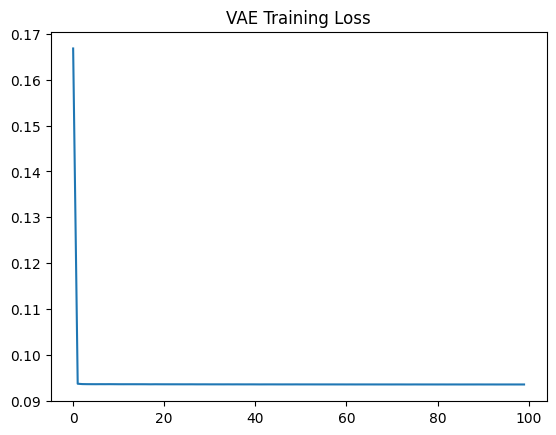

In [20]:

# --- 2. Variational Autoencoder (VAE) ---
# Enforces Gaussian Latent Structure using KL-Divergence Regularization

class VAE(nn.Module):
    def __init__(self, input_dim):
        super(VAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc2 = nn.Linear(16, 8)
        
        # Variational Layer (Mean and LogVar)
        self.fc_mu = nn.Linear(8, 2)
        self.fc_logvar = nn.Linear(8, 2)
        
        # Decoder
        self.fc3 = nn.Linear(2, 8)
        self.fc4 = nn.Linear(8, 16)
        self.fc5 = nn.Linear(16, input_dim)
        
    def encode(self, x):
        h1 = F.tanh(self.fc1(x))
        h2 = F.tanh(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h3 = F.tanh(self.fc3(z))
        h4 = F.tanh(self.fc4(h3))
        return torch.sigmoid(self.fc5(h4)) # Input is MinMaxScaled [0,1], matches Sigmoid
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Loss Function: Reconstruction + KL Divergence
def loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    # KLD = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # Beta weighting for KLD makes the latent space purely Gaussian vs Reconstruction quality
    beta = 2.0 
    return MSE + beta * KLD

# Init Model
device = torch.device("cpu")
input_dim = len(cols)
model = VAE(input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training Loop
print("Training VAE...")
dataset = TensorDataset(torch.FloatTensor(X_train_scaled))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

history_loss = []
for epoch in range(VAE_EPOCHS):
    train_loss = 0
    for batch in dataloader:
        x_batch = batch[0].to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(x_batch)
        loss = loss_function(recon_batch, x_batch, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    
    avg_loss = train_loss / len(dataloader.dataset)
    history_loss.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{VAE_EPOCHS}, Loss: {avg_loss:.4f}")

plt.plot(history_loss)
plt.title("VAE Training Loss")
plt.show()


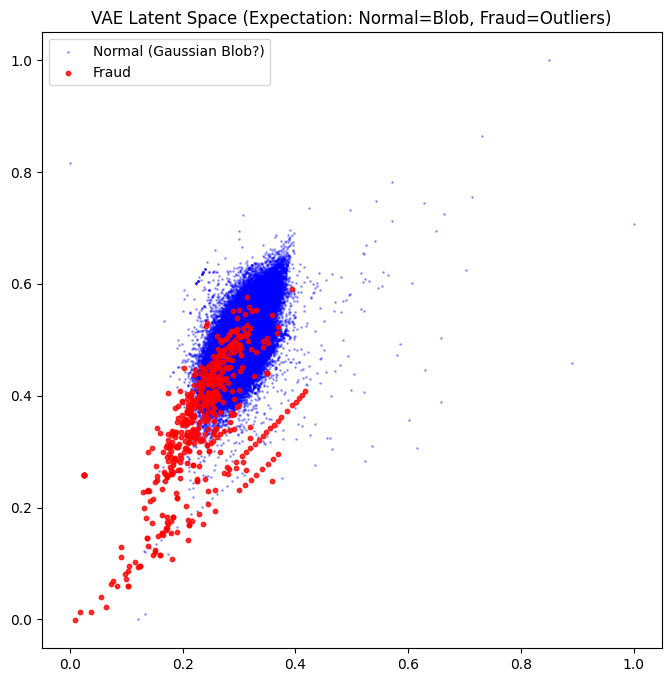

In [21]:

# --- 3. Generate Gaussian Latent Space ---

model.eval()
with torch.no_grad():
    # Use Mean (mu) as the deterministic embedding for visualization/usage
    mu, _ = model.encode(torch.FloatTensor(X_train_scaled).to(device))
    latent_normal = mu.numpy()

# Fit Scalar on Latent Space (Map unbounded Gaussian to [0, 1] for QCBM Grid)
latent_scaler = MinMaxScaler()
latent_normal = latent_scaler.fit_transform(latent_normal)

# Visualize Latent Space (Check for "Ball" shape)
with torch.no_grad():
    fraud_scaled = scaler.transform(df_fraud[cols].values)
    mu_fraud, _ = model.encode(torch.FloatTensor(fraud_scaled).to(device))
    latent_fraud_viz = latent_scaler.transform(mu_fraud.numpy())

plt.figure(figsize=(8,8))
plt.scatter(latent_normal[:, 0], latent_normal[:, 1], s=1, alpha=0.3, c='blue', label='Normal (Gaussian Blob?)')
plt.scatter(latent_fraud_viz[:, 0], latent_fraud_viz[:, 1], s=10, alpha=0.8, c='red', label='Fraud')
plt.title("VAE Latent Space (Expectation: Normal=Blob, Fraud=Outliers)")
plt.legend()
plt.show()


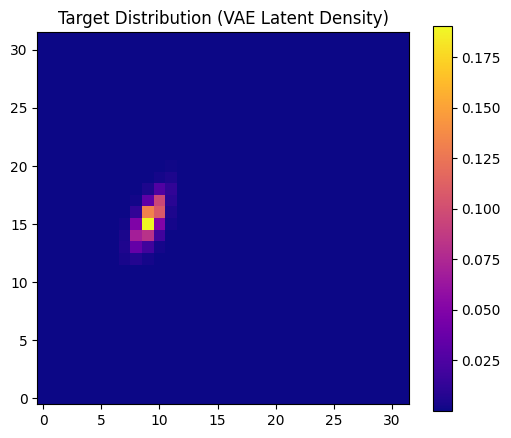

In [22]:

# --- 4. Grid Discretization ---

bins = np.linspace(0, 1, GRID_SIZE + 1)
x_bins = np.digitize(latent_normal[:, 0], bins) - 1
y_bins = np.digitize(latent_normal[:, 1], bins) - 1

x_bins = np.clip(x_bins, 0, GRID_SIZE - 1)
y_bins = np.clip(y_bins, 0, GRID_SIZE - 1)

combined_bins = x_bins * GRID_SIZE + y_bins
target_counts = np.bincount(combined_bins, minlength=2**N_QUBITS)
target_dist = target_counts / np.sum(target_counts)
target_dist = (target_dist + 1e-9) / np.sum(target_dist + 1e-9)

plt.figure(figsize=(6, 5))
plt.imshow(target_dist.reshape(GRID_SIZE, GRID_SIZE).T, origin='lower', cmap='plasma')
plt.title("Target Distribution (VAE Latent Density)")
plt.colorbar()
plt.show()


In [23]:

# --- 5. QCBM Training (10 Qubits) ---

simulator = AerSimulator()

def create_qcbm_circuit(params):
    qc = EfficientSU2(N_QUBITS, su2_gates=['ry', 'rz'], entanglement='full', reps=N_LAYERS)
    qc.measure_all()
    return qc.assign_parameters(params)

def get_qcbm_probs(params):
    qc = create_qcbm_circuit(params)
    qc_t = transpile(qc, simulator)
    result = simulator.run(qc_t, shots=SHOTS).result()
    probs = np.zeros(2**N_QUBITS)
    for k, v in result.get_counts().items():
        probs[int(k, 2)] = v
    return (probs / np.sum(probs)) + 1e-10

def cost_function(params):
    q_dist = get_qcbm_probs(params)
    return np.sum(target_dist * np.log(target_dist / q_dist))

# Optimize
qc_dummy = EfficientSU2(N_QUBITS, su2_gates=['ry', 'rz'], entanglement='full', reps=N_LAYERS)
n_params = len(qc_dummy.parameters)
initial_params = np.random.uniform(0, 2*np.pi, n_params)

print(f"Training QCBM on VAE Latent Space ({MAX_ITER_QCBM} iters)...")
res = minimize(cost_function, initial_params, method='COBYLA', options={'maxiter': MAX_ITER_QCBM, 'disp': True})
opt_params = res.x
print("Training Complete.")


Training QCBM on VAE Latent Space (300 iters)...
Training Complete.
   Return from subroutine COBYLA because the MAXFUN limit has been reached.

   NFVALS =  300   F = 2.728140E+00    MAXCV = 0.000000E+00
   X = 2.464732E+00   2.060690E+00   3.920389E+00   4.800869E+00   5.198049E+00
       2.061632E+00   4.311960E+00   1.414139E+00   1.929729E+00   2.796149E+00
       3.673410E+00   3.643047E+00   4.296898E+00   1.890013E+00   7.390937E-02
       7.039608E+00   3.488227E+00   2.725264E+00   2.650447E+00   3.234878E+00
       4.315659E+00   4.757706E+00   3.269607E+00   3.346404E+00   2.473423E-01
       4.373758E+00   1.721083E+00   5.923022E+00   6.198257E-01   4.321634E+00
       4.758013E+00   5.660683E+00   5.683595E+00   3.015993E+00   4.209493E+00
       1.212282E+00   3.411897E+00   2.648301E+00   3.984584E+00   3.402491E+00
       5.874594E+00   2.735573E+00   4.420785E+00   4.042183E+00   4.634736E+00
       5.414288E+00   4.335071E+00   3.225008E+00   4.487996E-01   5.182868

=== HYBRID VAE-QCBM RESULTS ===
Best F1 Score: 0.4456
Precision:     0.3920
Recall:        0.5163
ROC AUC:       0.8381


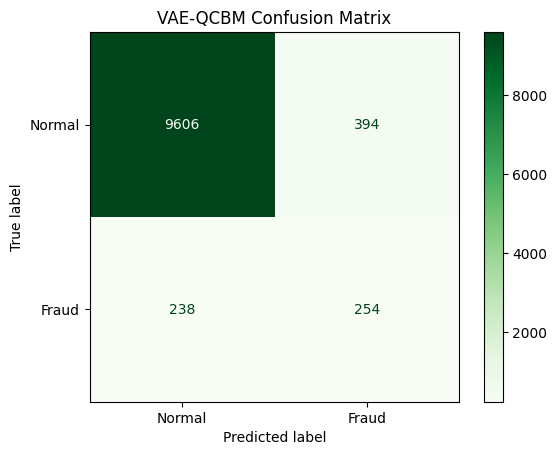

In [26]:

# --- 6. Evaluation (Disjoint Test Set) ---

# 1. Prepare Test Data
test_normal = df_normal_test.sample(n=min(10000, len(df_normal_test)), random_state=42)
test_df = pd.concat([test_normal, df_fraud])
y_test = test_df['Class'].values
X_test = test_df[cols].values

# 2. VAE Projection
X_test_scaled = scaler.transform(X_test)
with torch.no_grad():
    mu_test, _ = model.encode(torch.FloatTensor(X_test_scaled).to(device))
    latent_test = mu_test.numpy()

# 3. Scale & Bin
latent_test = latent_scaler.transform(latent_test) # Apply Latent Scaling!
tx_bins = np.digitize(latent_test[:, 0], bins) - 1
ty_bins = np.digitize(latent_test[:, 1], bins) - 1
tx_bins = np.clip(tx_bins, 0, GRID_SIZE - 1)
ty_bins = np.clip(ty_bins, 0, GRID_SIZE - 1)

# 4. Likelihoods
test_indices = tx_bins * GRID_SIZE + ty_bins
final_dist = get_qcbm_probs(opt_params)
likelihoods = final_dist[test_indices]

# 5. Thresholding
thresholds = np.linspace(np.min(likelihoods), np.max(likelihoods), 200)
best_f1, best_thresh = 0, 0
best_stats = {'Precision': 0, 'Recall': 0, 'AUC': 0, 'F1': 0}

for t in thresholds:
    preds = (likelihoods < t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
        best_stats = {
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall': recall_score(y_test, preds, zero_division=0),
            'F1': f1,
            'AUC': roc_auc_score(y_test, 1-likelihoods)
        }

print(f"=== HYBRID VAE-QCBM RESULTS ===")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Precision:     {best_stats['Precision']:.4f}")
print(f"Recall:        {best_stats['Recall']:.4f}")
print(f"ROC AUC:       {best_stats['AUC']:.4f}")

# Plot Confusion Matrix
final_preds = (likelihoods < best_thresh).astype(int)
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Greens')
plt.title("VAE-QCBM Confusion Matrix")
plt.show()
